In [1]:
# Standard library
import sys
from pathlib import Path
from dataclasses import dataclass, field

# Numerical computing
import numpy as np
from scipy.optimize import curve_fit

# Visualization
import matplotlib.pyplot as plt

# Data handling
from tqdm import tqdm

# Project imports
REPO_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "code"))

from config import (
    MNIST_LENS_DIR,
    MPEG7_LENS_DIR,
    FIGURE_DIR,
)

In [2]:
import matplotlib as mpl

scale = 1
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.titlesize": 8 * scale,
        "axes.labelsize": 8 * scale,
        "xtick.labelsize": 7 * scale,
        "ytick.labelsize": 7 * scale,
        "legend.fontsize": 7 * scale,
        "axes.linewidth": 0.7 * scale,
        "grid.linewidth": 0.5 * scale,
        "xtick.major.width": 0.6 * scale,
        "ytick.major.width": 0.6 * scale,
        "xtick.minor.width": 0.5 * scale,
        "ytick.minor.width": 0.5 * scale,
        "lines.linewidth": 0.5 * scale,
        "lines.markeredgewidth": 0.5 * scale,
        "lines.markersize": 2.5 * scale,
        "lines.marker": "o",
        "savefig.bbox": None,
        "savefig.pad_inches": 0.0 * scale,
    }
)


def adjust_fixed_margins(fig, left_in=0.55, right_in=0.08, bottom_in=0.45, top_in=0.18):
    """
    fix margins in inch：left/right/bottom/top
    """
    W, H = fig.get_size_inches()
    fig.subplots_adjust(
        left=left_in / W,
        right=1 - right_in / W,
        bottom=bottom_in / H,
        top=1 - top_in / H,
    )

In [3]:
fig_folder_dir = FIGURE_DIR
fig_dir = fig_folder_dir / "supp_EMCCDCalibration"
fig_dir.mkdir(parents=True, exist_ok=True)

# Shared Processing Code

In [4]:
"""Dataset-level abstraction: each DatasetSpec fully describes one acquisition."""

@dataclass
class DatasetSpec:
    name: str  # human label, e.g. "mnist_low"
    frames_dir: Path  # folder containing per-image .npz files
    dark_frames_path: Path  # background .npz
    n_images: int  # number of images in the dataset
    n_shots: int = 100  # frames per image
    frame_shape: tuple = (45, 45)  # (H, W)
    frame_filename_template: str = "{i}_EM_Gain_200.npz"

    # Bin configuration for the variance-vs-mean fit
    bin_centers: np.ndarray = field(default_factory=lambda: np.arange(6, 66) * 100)
    bin_half_width: float = 50.0
    pixels_per_bin: int = 20

    # Dark-noise fit range (can be left as defaults most of the time)
    dark_hist_range: tuple = (500, 1300)
    dark_n_bins: int = 400
    dark_n_sigma: int = 3
    dark_gaussian_fit_window: tuple = (530, 650)
    dark_tail_fit_window: tuple = (650, 850)

    # Reference photon count if you want to compare (optional, can be None)
    reference_photons_per_frame: float | None = None

    @property
    def n_pixels_per_frame(self) -> int:
        return self.frame_shape[0] * self.frame_shape[1]

In [5]:
def log_gaussian_plus_exp_tail(x, offset, sigma, amplitude, tail_slope, tail_intercept):
    gaussian = amplitude * np.exp(-0.5 * ((x - offset) / sigma) ** 2)
    tail = np.exp(tail_slope * x + tail_intercept) * (x >= offset)
    return np.log(gaussian + tail)


def fit_dark_noise(
    dark_frames,
    hist_range=(500, 1300),
    n_bins=400,
    n_sigma=3,
    initial_guess=(604, 18, 7500, -0.022, 19.27),
    gaussian_fit_window=(530, 650),
    tail_fit_window=(650, 850),
):
    """Fit the Gaussian+exp model to a stack of dark frames.

    Parameters
    ----------
    gaussian_fit_window : (lo, hi)
        Range of measured values used to constrain the Gaussian readout peak.
    tail_fit_window : (lo, hi)
        Range of measured values used to constrain the exponential CIC tail.
    """
    values = dark_frames.flatten()
    counts, edges = np.histogram(values, bins=n_bins, range=hist_range)
    centers = 0.5 * (edges[:-1] + edges[1:])

    gauss_lo, gauss_hi = gaussian_fit_window
    tail_lo, tail_hi = tail_fit_window
    fit_mask = ((centers > gauss_lo) & (centers < gauss_hi)) | (
        (centers > tail_lo) & (centers < tail_hi)
    )

    popt, _ = curve_fit(
        log_gaussian_plus_exp_tail,
        centers[fit_mask],
        np.log(np.maximum(counts[fit_mask], 1)),
        p0=initial_guess,
    )
    offset, sigma, amplitude, tail_slope, tail_intercept = popt
    return {
        "offset": offset,
        "readout_sigma": sigma,
        "amplitude": amplitude,
        "tail_slope": tail_slope,
        "tail_intercept": tail_intercept,
        "threshold": offset + n_sigma * sigma,
        "n_sigma": n_sigma,
        "hist_counts": counts,
        "hist_centers": centers,
        "hist_range": hist_range,
        "n_bins": n_bins,
        "gaussian_fit_window": gaussian_fit_window,
        "tail_fit_window": tail_fit_window,
        "fit_mask": fit_mask,
        "params": popt,
    }


def plot_dark_histogram(dark_frames, fit, title, save_path=None, fig_size=(3.2, 2.3)):
    offset, sigma, thresh = fit["offset"], fit["readout_sigma"], fit["threshold"]
    a = fit["tail_slope"]
    centers = fit["hist_centers"]
    gauss_lo, gauss_hi = fit["gaussian_fit_window"]
    tail_lo, tail_hi = fit["tail_fit_window"]

    fig, ax = plt.subplots(figsize=fig_size, dpi=150)
    ax.hist(
        dark_frames.flatten(),
        bins=fit["n_bins"],
        range=fit["hist_range"],
        alpha=0.5,
        label="Background",
    )

    # Draw model curves only over their respective fit windows
    x_gauss = centers[(centers > gauss_lo) & (centers < gauss_hi)]
    x_tail = centers[(centers > tail_lo) & (centers < tail_hi)]
    ax.plot(
        x_gauss,
        np.exp(log_gaussian_plus_exp_tail(x_gauss, *fit["params"])),
        "b",
        lw=0.5,
        ms=0.5,
    )
    ax.plot(
        x_tail,
        np.exp(log_gaussian_plus_exp_tail(x_tail, *fit["params"])),
        "r",
        lw=0.5,
        ms=0.5,
    )

    ax.axvline(thresh, color="g", ls="--", lw=0.5)
    ax.text(
        offset + 6 * sigma,
        0.1 * fit["hist_counts"].max(),
        f"$\\mu={offset:.0f}, \\sigma={sigma:.0f}$\n threshold $={thresh:.0f}$",
        ha="left",
        fontsize=7,
    )
    ax.text(
        offset + 9 * sigma,
        20,
        f"slope = {a:.3f}\n 1/$|$slope$|$ = {1/abs(a):.2f}",
        ha="left",
        fontsize=7,
    )

    ax.set_yscale("log")
    ax.set_ylim(0.8, 2.5e4)
    ax.set_xlabel(r"Measured value ($\mathrm{gl}$)")
    ax.set_ylabel("Frequency: number of pixels")
    ax.set_title(title)

    fig.tight_layout()
    adjust_fixed_margins(fig, left_in=0.45, bottom_in=0.35, right_in=0.15, top_in=0.18)
    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches=None, pad_inches=0.0)
    return fig, ax


def save_background(save_path, fit):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        save_path,
        params=fit["params"],
        offset=fit["offset"],
        readout_sigma=fit["readout_sigma"],
        tail_slope=fit["tail_slope"],
        threshold=fit["threshold"],
    )

In [6]:
def load_image_stack(spec: DatasetSpec):
    """Load frames for a single dataset, return (time_mean, time_raw)."""
    n_pixels = spec.n_pixels_per_frame
    time_mean_list, time_raw_list = [], []
    for i in tqdm(range(spec.n_images), desc=f"loading {spec.name}"):
        fname = spec.frame_filename_template.format(i=i)
        frames = np.load(spec.frames_dir / fname)["data"]  # (n_shots, H, W)
        time_mean_list.append(frames.mean(axis=0).reshape(-1))
        time_raw_list.append(frames.reshape(spec.n_shots, n_pixels).T)
    return (np.concatenate(time_mean_list), np.concatenate(time_raw_list, axis=0))


def group_by_mean(
    pixel_time_mean,
    pixel_time_raw,
    bin_centers,
    half_width,
    pixels_per_bin=20,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng(0)

    kept, means, variances, var_sem = [], [], [], []
    for center in bin_centers:
        idx = np.where(
            (pixel_time_mean >= center - half_width)
            & (pixel_time_mean < center + half_width)
        )[0]
        if idx.size < pixels_per_bin:
            continue

        chosen = rng.choice(idx, size=pixels_per_bin, replace=False)
        values = pixel_time_raw[chosen].reshape(-1)

        n = values.size
        var = values.var(ddof=1)

        kept.append(center)
        means.append(values.mean())
        variances.append(var)
        var_sem.append(var * np.sqrt(2.0 / (n - 1)))

    return (
        np.asarray(kept),
        np.asarray(means),
        np.asarray(variances),
        np.asarray(var_sem),
    )


@dataclass
class LinearFit:
    slope: float
    intercept: float
    slope_err: float
    intercept_err: float
    r_squared: float


def weighted_linear_fit(x, y, y_sem) -> LinearFit:
    w = 1.0 / np.maximum(y_sem, 1e-12) ** 2
    S, Sx, Sy = w.sum(), (w * x).sum(), (w * y).sum()
    Sxx, Sxy = (w * x * x).sum(), (w * x * y).sum()
    det = S * Sxx - Sx * Sx
    slope = (S * Sxy - Sx * Sy) / det
    intercept = (Sxx * Sy - Sx * Sxy) / det
    slope_err = np.sqrt(S / det)
    intercept_err = np.sqrt(Sxx / det)
    r2 = 1 - np.sum((y - slope * x - intercept) ** 2) / np.sum((y - y.mean()) ** 2)
    return LinearFit(slope, intercept, slope_err, intercept_err, r2)


def plot_variance_vs_mean(
    mean_gl,
    var_gl2,
    var_sem,
    fit: LinearFit,
    background_gl,
    title,
    save_path=None,
    fig_size=(3.2, 2.3),
):
    gain, gain_err = fit.slope / 2.0, fit.slope_err / 2.0
    x = mean_gl - background_gl

    fig, ax = plt.subplots(figsize=fig_size, dpi=150)
    ax.errorbar(
        x,
        var_gl2,
        yerr=var_sem,
        fmt="o",
        ms=2.5,
        lw=0.6,
        capsize=1.5,
        color="tab:blue",
        label="data",
    )
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(
        x_line,
        fit.slope * x_line + fit.intercept,
        "r--",
        lw=1.0,
        label=(
            f"fit: $y=a\\,x+b$\n"
            f"$a$ = {fit.slope:.2f} ± {fit.slope_err:.2f}\n"
            f"$b$ = {fit.intercept:.1f} ± {fit.intercept_err:.1f}\n"
            f"$g=a/2$ = {gain:.2f} ± {gain_err:.2f}\n"
            f"$R^2$ = {fit.r_squared:.4f}"
        ),
    )
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.set_xlabel(r"Mean value $-$ background ($\mathrm{gl}$)")
    ax.set_ylabel(r"Variance ($\mathrm{gl}^2$)")
    ax.set_title(title)
    ax.grid(alpha=0.9, which="major", linestyle="--")
    ax.legend(loc="upper left", fontsize=6.5, frameon=False)
    fig.tight_layout()
    adjust_fixed_margins(fig, left_in=0.45, bottom_in=0.35, right_in=0.15, top_in=0.18)
    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=600,
            bbox_inches=None,
            pad_inches=0.0,
        )
    return fig, ax

In [7]:
QUANTUM_EFFICIENCY = 0.65


def estimate_photons_per_frame(
    pixel_time_mean, background_offset, gain, quantum_efficiency, n_pixels_per_frame
):
    signal_gl = pixel_time_mean - background_offset
    photons_per_pixel = signal_gl / (quantum_efficiency * gain)
    n_frames = pixel_time_mean.size // n_pixels_per_frame
    photons_per_frame = photons_per_pixel.reshape(n_frames, n_pixels_per_frame).sum(
        axis=1
    )
    return {
        "photons_per_frame": photons_per_frame,
        "mean_photons_per_frame": photons_per_frame.mean(),
        "std_photons_per_frame": photons_per_frame.std(ddof=1),
        "photons_per_pixel": photons_per_pixel,
    }

In [8]:
def process_dataset(
    spec: DatasetSpec, fig_dir: Path, quantum_efficiency=QUANTUM_EFFICIENCY
):
    """End-to-end pipeline for one dataset. Returns everything in a dict."""
    # --- dark-frame fit ---
    dark_frames = np.load(spec.dark_frames_path)["data"]
    dark_fit = fit_dark_noise(
        dark_frames,
        hist_range=spec.dark_hist_range,
        n_bins=spec.dark_n_bins,
        n_sigma=spec.dark_n_sigma,
        gaussian_fit_window=spec.dark_gaussian_fit_window,
        tail_fit_window=spec.dark_tail_fit_window,
    )

    dark_mean_global = dark_frames.mean()
    dark_std_global = dark_frames.std(ddof=1)
    print(f"[{spec.name}]")
    print(f"           empirical dark mean = {dark_mean_global:.2f} gl")
    print(f"           empirical dark std  = {dark_std_global:.2f} gl")
    print(f"dark-noise fit:")
    print(f"           mu (offset)     = {dark_fit['offset']:.2f} gl")
    print(f"           sigma (readout) = {dark_fit['readout_sigma']:.2f} gl")
    print(
        f"           tail slope      = {dark_fit['tail_slope']:.4f}  "
        f"(1/|slope| = {1/abs(dark_fit['tail_slope']):.2f} gl)"
    )
    print(
        f"           threshold (mu+{dark_fit['n_sigma']}sigma) = "
        f"{dark_fit['threshold']:.2f} gl"
    )

    plot_dark_histogram(
        dark_frames,
        dark_fit,
        title=f"{spec.name}: dark-frame histogram",
        save_path=fig_dir / f"dark_hist_{spec.name}.svg",
    )
    save_background(spec.frames_dir.parent / "background.npz", dark_fit)

    # --- load frames ---
    pixel_time_mean, pixel_time_raw = load_image_stack(spec)

    # --- variance-vs-mean fit for gain ---
    centers, pooled_mean, pooled_var, pooled_var_sem = group_by_mean(
        pixel_time_mean,
        pixel_time_raw,
        spec.bin_centers,
        spec.bin_half_width,
        spec.pixels_per_bin,
    )
    fit = weighted_linear_fit(
        pooled_mean - dark_fit["offset"],
        pooled_var,
        pooled_var_sem,
    )
    plot_variance_vs_mean(
        mean_gl=pooled_mean,
        var_gl2=pooled_var,
        var_sem=pooled_var_sem,
        fit=fit,
        background_gl=dark_fit["offset"],
        title=f"{spec.name}: variance vs. mean",
        save_path=fig_dir / f"var_mean_fit_{spec.name}.svg",
    )
    gain = fit.slope / 2.0
    gain_err = fit.slope_err / 2.0

    # --- photons per frame ---
    photons = estimate_photons_per_frame(
        pixel_time_mean=pixel_time_mean,
        background_offset=dark_mean_global,
        gain=gain,
        quantum_efficiency=quantum_efficiency,
        n_pixels_per_frame=spec.n_pixels_per_frame,
    )
    mean_n = photons["mean_photons_per_frame"]
    mean_n_err = mean_n * (gain_err / gain)

    print(f"gain fit:")
    print(
        f"           g = {gain:.2f} ± {gain_err:.2f}  " f"(R^2 = {fit.r_squared:.4f})"
    )
    msg = f"           photons/frame = {mean_n:.1f} ± {mean_n_err:.1f}"
    if spec.reference_photons_per_frame is not None:
        ref = spec.reference_photons_per_frame
        msg += f"  (ref ≈ {ref}; {mean_n/ref*100:.1f}%)"
    print(msg)
    print(
        f"           std across frames = "
        f"{photons['std_photons_per_frame']:.1f} photons"
    )

    return {
        "spec": spec,
        "dark_fit": dark_fit,
        "pixel_time_mean": pixel_time_mean,
        "pixel_time_raw": pixel_time_raw,
        "variance_fit": fit,
        "gain": gain,
        "gain_err": gain_err,
        **photons,
        "mean_n_err_from_gain": mean_n_err,
    }

# MNIST

[MNIST, low power]
           empirical dark mean = 605.04 gl
           empirical dark std  = 22.02 gl
dark-noise fit:
           mu (offset)     = 604.03 gl
           sigma (readout) = 18.39 gl
           tail slope      = -0.0218  (1/|slope| = 45.93 gl)
           threshold (mu+3sigma) = 659.20 gl


loading MNIST, low power: 100%|██████████| 12000/12000 [00:24<00:00, 498.44it/s]


gain fit:
           g = 53.82 ± 0.39  (R^2 = 0.9962)
           photons/frame = 51.7 ± 0.4  (ref ≈ 65; 79.5%)
           std across frames = 11.8 photons
[MNIST, high power]
           empirical dark mean = 606.04 gl
           empirical dark std  = 22.18 gl
dark-noise fit:
           mu (offset)     = 604.85 gl
           sigma (readout) = 17.68 gl
           tail slope      = -0.0228  (1/|slope| = 43.94 gl)
           threshold (mu+3sigma) = 657.89 gl


loading MNIST, high power: 100%|██████████| 12000/12000 [00:27<00:00, 437.10it/s]


gain fit:
           g = 59.06 ± 0.25  (R^2 = 0.8984)
           photons/frame = 1066.5 ± 4.4  (ref ≈ 1210; 88.1%)
           std across frames = 43.7 photons


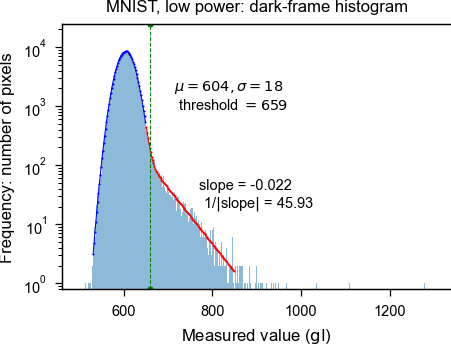

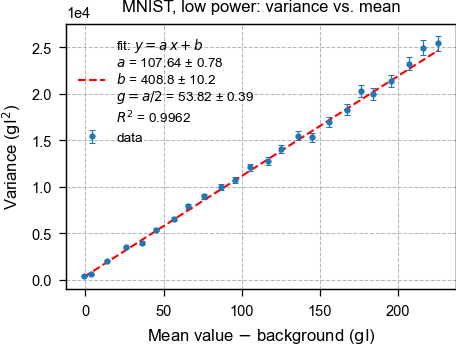

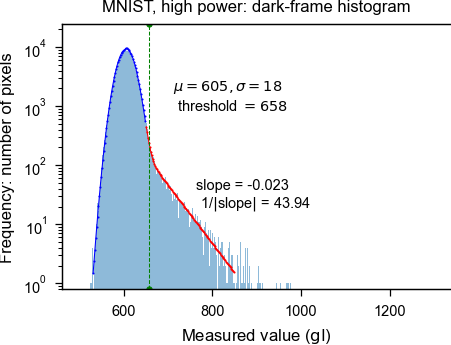

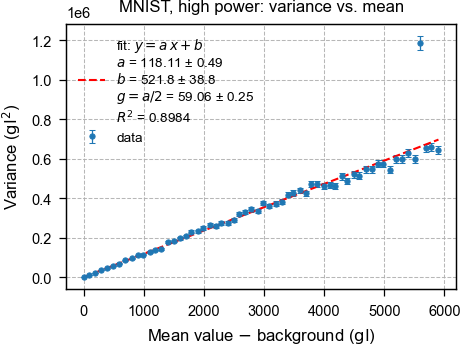

In [9]:
# --- MNIST datasets ---
mnist_low = DatasetSpec(
    name="MNIST, low power",
    frames_dir=MNIST_LENS_DIR["low"] / "frames",
    dark_frames_path=MNIST_LENS_DIR["low"]
    / "raw_dark_frames/Background_100_frames_10ms_exposure_200_EMGain.npz",
    n_images=12000,
    bin_centers=np.arange(60, 84) * 10,
    bin_half_width=5,
    reference_photons_per_frame=65,
)
mnist_high = DatasetSpec(
    name="MNIST, high power",
    frames_dir=MNIST_LENS_DIR["high"] / "frames",
    dark_frames_path=MNIST_LENS_DIR["high"]
    / "raw_dark_frames/Background_100_frames_10ms_exposure_200_EMGain.npz",
    n_images=12000,
    bin_centers=np.arange(6, 66) * 100,
    bin_half_width=50,
    reference_photons_per_frame=1210,
)

# --- run ---
datasets = [mnist_low, mnist_high]
results = {spec.name: process_dataset(spec, fig_dir) for spec in datasets}

# MPEG-7

In [10]:
# --- MPEG7 dataset (fill in when you have it) ---
mpeg7 = DatasetSpec(
    name="MPEG-7",
    frames_dir=MPEG7_LENS_DIR / "frames",
    dark_frames_path=MPEG7_LENS_DIR
    / "raw_dark_frames/Background_300_frames_15ms_exposure_1000_EMGain.npz",
    n_images=1400,
    bin_centers=np.arange(6, 100) * 100,  # choose per your data range
    bin_half_width=50,
    n_shots=300,
    frame_shape=(39, 39),  # change if your camera ROI differs
    frame_filename_template="{i}_EM_Gain_1000.npz",
    dark_gaussian_fit_window=(530, 650),
    dark_tail_fit_window=(750, 1200),
    reference_photons_per_frame=800,  # if unknown
)

[MPEG-7]
           empirical dark mean = 603.19 gl
           empirical dark std  = 56.18 gl
dark-noise fit:
           mu (offset)     = 596.41 gl
           sigma (readout) = 14.52 gl
           tail slope      = -0.0066  (1/|slope| = 150.52 gl)
           threshold (mu+3sigma) = 639.96 gl


loading MPEG-7: 100%|██████████| 1400/1400 [00:07<00:00, 193.26it/s]


gain fit:
           g = 166.41 ± 0.34  (R^2 = 0.9979)
           photons/frame = 1231.6 ± 2.5  (ref ≈ 800; 153.9%)
           std across frames = 71.4 photons


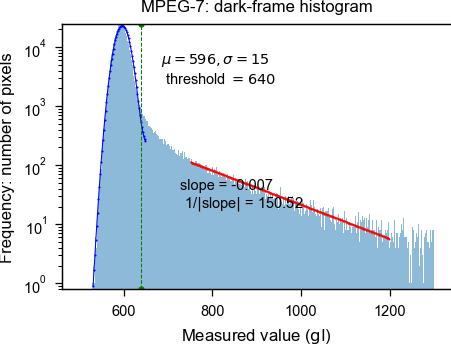

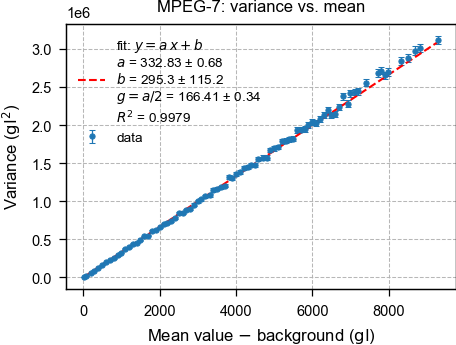

In [11]:
results[mpeg7.name] = process_dataset(mpeg7, fig_dir)